# MS Lesion Segmentation (MSLesSeg) — Runner

Notebook unico che funziona **in locale da VS Code** e **su Colab**. Rileva l'ambiente,
si posiziona nella root del repo, carica la config e ispeziona/visualizza il dataset.
Il codice vero sta in `src/` (versionato): il notebook è solo il "driver".


## 1. Ambiente + root del repo
Rileva Colab vs locale, trova la cartella del repo e la imposta come working dir.

In [1]:
import os, sys

def find_repo_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.exists(os.path.join(d, "configs", "base.yaml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    raise FileNotFoundError("Root del repo non trovata: apri la cartella 'ms-lesion-seg' in VS Code.")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Se il repo è su GitHub, decommenta e adatta:
    # !git clone https://github.com/<TUO_UTENTE>/ms-lesion-seg.git /content/ms-lesion-seg
    # os.chdir("/content/ms-lesion-seg")

REPO = find_repo_root()
os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)
print("Ambiente:", "Colab" if IN_COLAB else "Locale (VS Code)")
print("Repo root:", REPO)

Ambiente: Locale (VS Code)
Repo root: c:\Users\massi\Documents\GitHub\ms-lesion-seg


## 2. Dipendenze
In locale eseguile **una volta** nel tuo ambiente conda/venv, poi ricommenta la riga.

In [2]:
# %pip install "monai>=1.3" nibabel SimpleITK omegaconf scikit-image matplotlib pandas
# Nota: su Colab torch c'è già. In locale con GPU installa il build CUDA da pytorch.org.
import importlib.util
for m in ["omegaconf", "nibabel", "numpy", "pandas", "matplotlib"]:
    print(f"  {m}:", "OK" if importlib.util.find_spec(m) else "MANCANTE (installa)")

  omegaconf: OK
  nibabel: OK
  numpy: OK
  pandas: OK
  matplotlib: OK


## 3. Carica config + indicizza il dataset (Fase 1)
Usa i path in `configs/base.yaml`. Verifica che gli esempi di filename combacino col pattern.

In [3]:
from src.config import load_config
from src.data.indexing import discover_cases, attach_metadata, make_patient_splits
from collections import Counter

cfg = load_config("configs/base.yaml")
root = os.path.join(cfg.paths.data_root, "train")
cases = discover_cases(root, cfg.data.filename_pattern, cfg.data.modality_aliases)
cases = attach_metadata(cases, cfg.paths.metadata_csv)

n_pat = len({c["patient"] for c in cases})
print(f"Casi (train): {len(cases)} | pazienti: {n_pat}")
train, val = make_patient_splits(cases, val_fraction=0.2, seed=cfg.project.seed)
print(f"Split per paziente -> train: {len(train)} casi | val: {len(val)} casi (no leakage)")
print("\nSottogruppi:")
for k in ("sex", "age_band", "field_strength"):
    print(f"  {k}: {dict(Counter(str(c.get(k, 'NA')) for c in cases))}")

Casi (train): 93 | pazienti: 53
Split per paziente -> train: 77 casi | val: 16 casi (no leakage)

Sottogruppi:
  sex: {'F': 54, 'M': 39}
  age_band: {'18-29': 30, '30-44': 44, '45+': 19}
  field_strength: {'NA': 93}


## 4. Visualizzazione (EDA)
Slice assiale con più lesione: FLAIR, maschera e overlay. Feedback visivo immediato in VS Code.

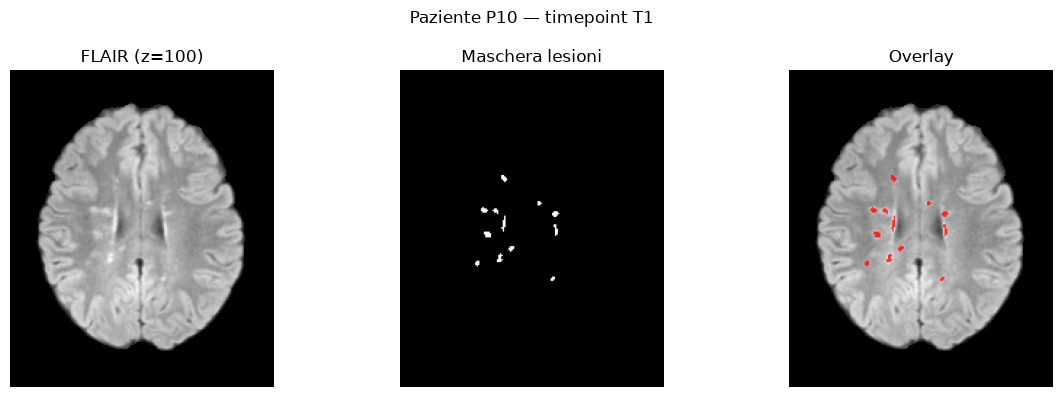

In [4]:
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt

case = next(c for c in cases if c["mask"])
flair = np.asarray(nib.load(case["images"]["FLAIR"]).dataobj)
mask = np.asarray(nib.load(case["mask"]).dataobj)
z = int(np.argmax(mask.sum(axis=(0, 1))))  # slice con area lesionale massima

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.rot90(flair[:, :, z]), cmap="gray"); ax[0].set_title(f"FLAIR (z={z})")
ax[1].imshow(np.rot90(mask[:, :, z]), cmap="gray");  ax[1].set_title("Maschera lesioni")
ax[2].imshow(np.rot90(flair[:, :, z]), cmap="gray")
overlay = np.ma.masked_where(mask[:, :, z] == 0, mask[:, :, z])
ax[2].imshow(np.rot90(overlay), cmap="autumn", alpha=0.8); ax[2].set_title("Overlay")
for a in ax:
    a.axis("off")
plt.suptitle(f"Paziente {case['patient']} — timepoint {case['timepoint']}")
plt.tight_layout(); plt.show()

## 5. Preprocessing (Fase 2)
Normalizza le intensità per modalità, ritaglia al cervello, porta le slice a
`data.spatial_size` e salva `.npy` + `meta.json` in `paths.processed_root`.

**Da eseguire una volta sola** (~1-2 min, ~4.8 GB su disco fra train e test).
I run successivi saltano i casi già presenti (usa `--force` per rifarli).

In [5]:
# Preprocessing completo (train + test). I casi già presenti vengono saltati,
# quindi rieseguire questa cella è sicuro e veloce.
!python scripts/01_preprocess.py --split train
!python scripts/01_preprocess.py --split test

# Prova rapida su pochi casi (solo per il primissimo collaudo):
# !python scripts/01_preprocess.py --split train --limit 3

[*] Sorgente : C:/Users/massi/Desktop/MSLesSeg Dataset\train
[*] Output   : C:/Users/massi/Desktop/MSLesSeg_Processed\train
[*] Casi     : 93 | modalità: ['FLAIR', 'T1', 'T2'] | slice [192, 192]

  [1/93] P1_T1: già presente (salto)
  [2/93] P1_T2: già presente (salto)
  [3/93] P1_T3: già presente (salto)
  [4/93] P10_T1: già presente (salto)
  [5/93] P10_T2: già presente (salto)
  [6/93] P11_T1: già presente (salto)
  [7/93] P11_T2: già presente (salto)
  [8/93] P12_T1: già presente (salto)
  [9/93] P12_T2: già presente (salto)
  [10/93] P12_T3: già presente (salto)
  [11/93] P12_T4: già presente (salto)
  [12/93] P13_T1: già presente (salto)
  [13/93] P13_T2: già presente (salto)
  [14/93] P14_T1: già presente (salto)
  [15/93] P14_T2: già presente (salto)
  [16/93] P14_T3: già presente (salto)
  [17/93] P14_T4: già presente (salto)
  [18/93] P15_T1: già presente (salto)
  [19/93] P16_T1: già presente (salto)
  [20/93] P17_T1: già presente (salto)
  [21/93] P18_T1: già presente (salt

## 6. Dataset 2.5D + DataLoader
Costruisce gli split, il dataset di slice e il sampler bilanciato.

In [6]:
from src.data.preprocessing import load_index
from src.data.dataset import build_dataloaders
from src.data.indexing import make_patient_splits

cfg = load_config("configs/base.yaml")
proc_cases = load_index(cfg.paths.processed_root, "train")
tr_cases, va_cases = make_patient_splits(proc_cases, 0.2, cfg.project.seed)

train_loader, val_loader, train_ds, val_ds = build_dataloaders(cfg, tr_cases, va_cases)
print(f"Casi preprocessati: {len(proc_cases)} -> train {len(tr_cases)} / val {len(va_cases)}")
print(f"Slice: train {len(train_ds)} | val {len(val_ds)}")
print(f"Slice con lesione (naturale): {train_ds.is_positive.mean()*100:.1f}% "
      f"-> sovracampionate al {cfg.data.pos_neg_ratio*100:.0f}%")

batch = next(iter(train_loader))
print(f"\nBatch -> image {tuple(batch['image'].shape)} | label {tuple(batch['label'].shape)}")
print(f"Canali attesi: {cfg.model.in_channels} "
      f"({len(cfg.data.modalities)} modalità x {2*cfg.data.context_slices+1} slice)")

Casi preprocessati: 93 -> train 77 / val 16
Slice: train 12022 | val 2525
Slice con lesione (naturale): 47.5% -> sovracampionate al 50%

Batch -> image (16, 9, 192, 192) | label (16, 1, 192, 192)
Canali attesi: 9 (3 modalità x 3 slice)


## 7. Sanity check visivo del batch
Controllo che immagine e maschera restino allineate dopo le augmentation.

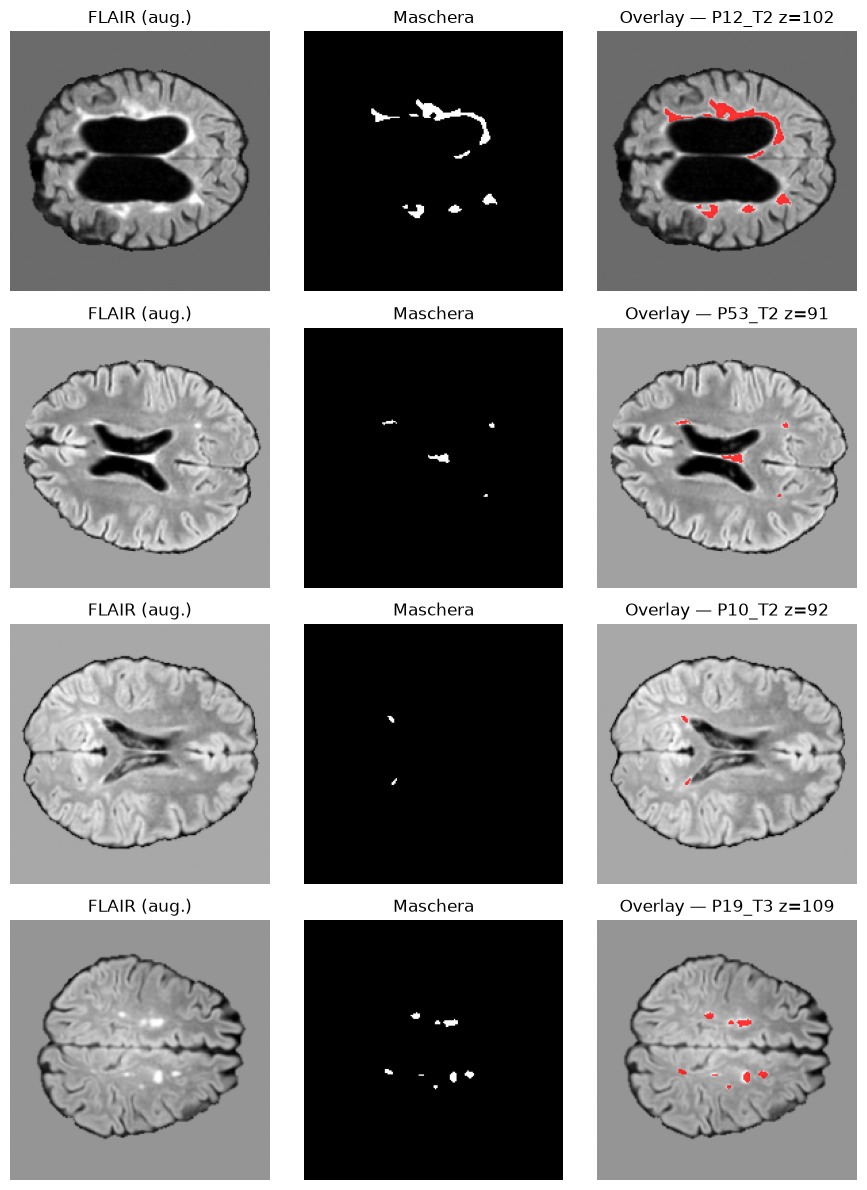

In [7]:
import matplotlib.pyplot as plt
import numpy as np

ctr = cfg.data.context_slices  # indice del canale centrale (slice della GT)
pos = [i for i in range(len(batch["label"])) if batch["label"][i].sum() > 0][:4]
if not pos:
    print("Nessuna slice con lesione in questo batch: rilancia la cella.")
else:
    fig, axes = plt.subplots(len(pos), 3, figsize=(9, 3*len(pos)), squeeze=False)
    for r, i in enumerate(pos):
        img = batch["image"][i, ctr].numpy()          # FLAIR, slice centrale
        lab = batch["label"][i, 0].numpy()
        axes[r][0].imshow(img, cmap="gray"); axes[r][0].set_title("FLAIR (aug.)")
        axes[r][1].imshow(lab, cmap="gray"); axes[r][1].set_title("Maschera")
        axes[r][2].imshow(img, cmap="gray")
        axes[r][2].imshow(np.ma.masked_where(lab == 0, lab), cmap="autumn", alpha=0.8)
        axes[r][2].set_title(f"Overlay — {batch['case'][i]} z={int(batch['z'][i])}")
        for a in axes[r]: a.axis("off")
    plt.tight_layout(); plt.show()

## 8. Visualizzazione e analisi qualitativa

Le metriche dicono *quanto* il modello sbaglia, le figure dicono *come*. Codifica colori:
**verde** = TP (lesione trovata), **rosso** = FN (mancata), **blu** = FP (falso allarme).

Imposta `RUN` sull'esperimento da analizzare (deve avere `best.pth` e la valutazione fatta).

In [8]:
import os, numpy as np, torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.data.preprocessing import load_index
from src.data.transforms import build_transforms
from src.evaluate import predict_case, _remove_small_components
from src.models.build import build_model
from src.visualize import (plot_training_curves, plot_results_overview,
                           plot_case_overlay, plot_lesion_zoom, overlay_rgb)

RUN   = "runs/unet_flair"     # <-- esperimento da analizzare
SPLIT = "test"
DEVICE = "cpu"                # "cpu" se la GPU è occupata da un training

cfg = OmegaConf.load(os.path.join(RUN, "config_resolved.yaml"))
cases = load_index(cfg.paths.processed_root, SPLIT)
by_name = {f"{c['patient']}_{c['timepoint']}": c for c in cases}
print(f"{len(cases)} casi disponibili:", list(by_name)[:6], "...")

22 casi disponibili: ['P54_T1', 'P55_T1', 'P56_T1', 'P57_T1', 'P58_T1', 'P59_T1'] ...


### 8.1 Curve di apprendimento e panoramica dei risultati

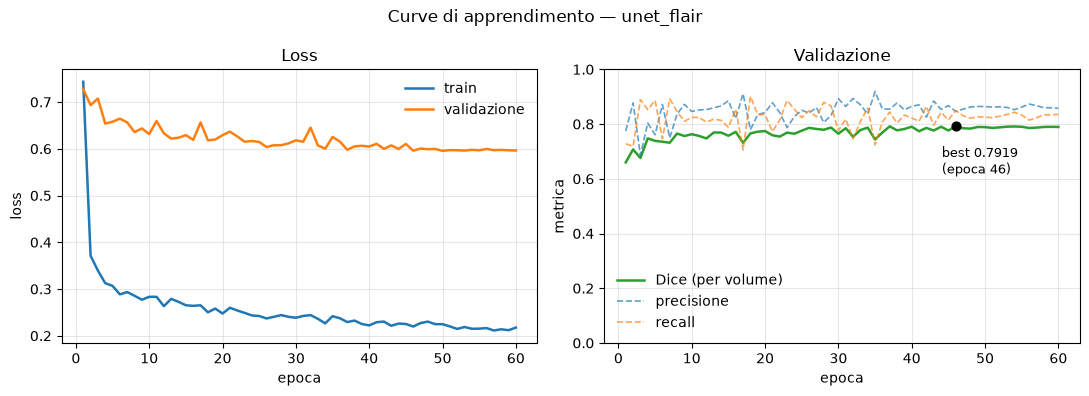

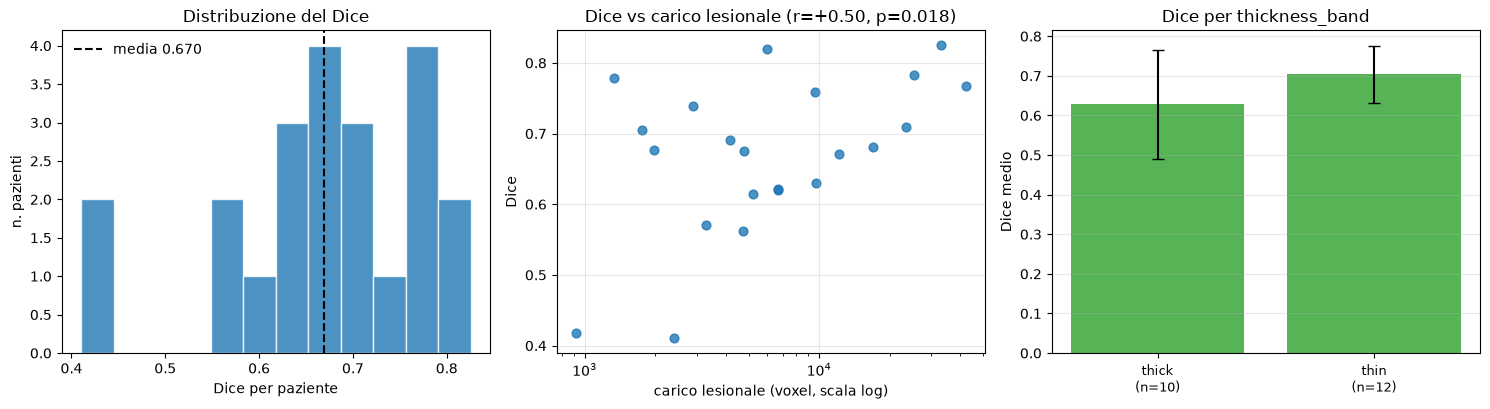

In [9]:
plot_training_curves(RUN, save=False); plt.show()

res_csv = os.path.join(RUN, f"eval_{SPLIT}", "results_per_case.csv")
if os.path.exists(res_csv):
    plot_results_overview(res_csv); plt.show()
else:
    print("Esegui prima: python scripts/03_evaluate.py --run", RUN, "--split", SPLIT)

### 8.2 Predizione su un caso
Carica il modello e calcola il volume predetto per il caso scelto.

In [10]:
CASE = list(by_name)[0]        # <-- cambia il caso da ispezionare

device = torch.device(DEVICE)
model = build_model(cfg)
ckpt = torch.load(os.path.join(RUN, "best.pth"), map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model"]); model = model.to(device).eval()
_, eval_tf = build_transforms(cfg)

meta = by_name[CASE]
prob = predict_case(model, meta, cfg, device, eval_tf)
pred = _remove_small_components(prob > float(cfg.eval.threshold),
                                int(cfg.eval.get("postproc_min_size", 0)))
gt  = np.load(os.path.join(meta["dir"], "mask.npy")) > 0
img = np.load(os.path.join(meta["dir"], f"{cfg.data.modalities[0]}.npy")).astype(np.float32)
dice = 2*(gt & pred).sum() / max(gt.sum()+pred.sum(), 1)
print(f"{CASE}: Dice {dice:.4f} | lesione GT {gt.sum()} voxel | predetta {pred.sum()} voxel")

P54_T1: Dice 0.7785 | lesione GT 1332 voxel | predetta 1679 voxel


### 8.3 Overlay sulle slice più lesionate e zoom sulle singole lesioni

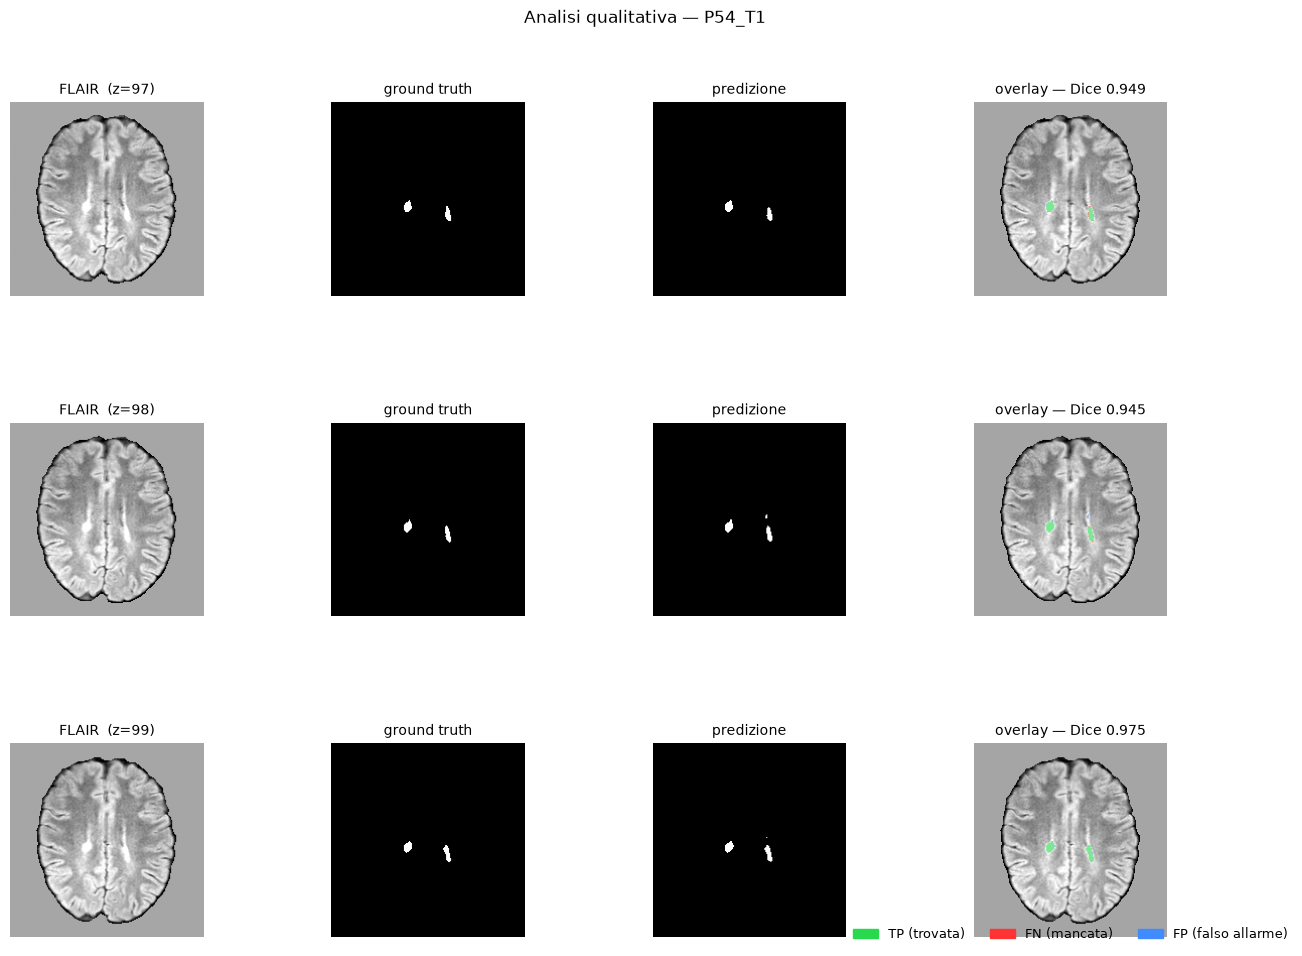

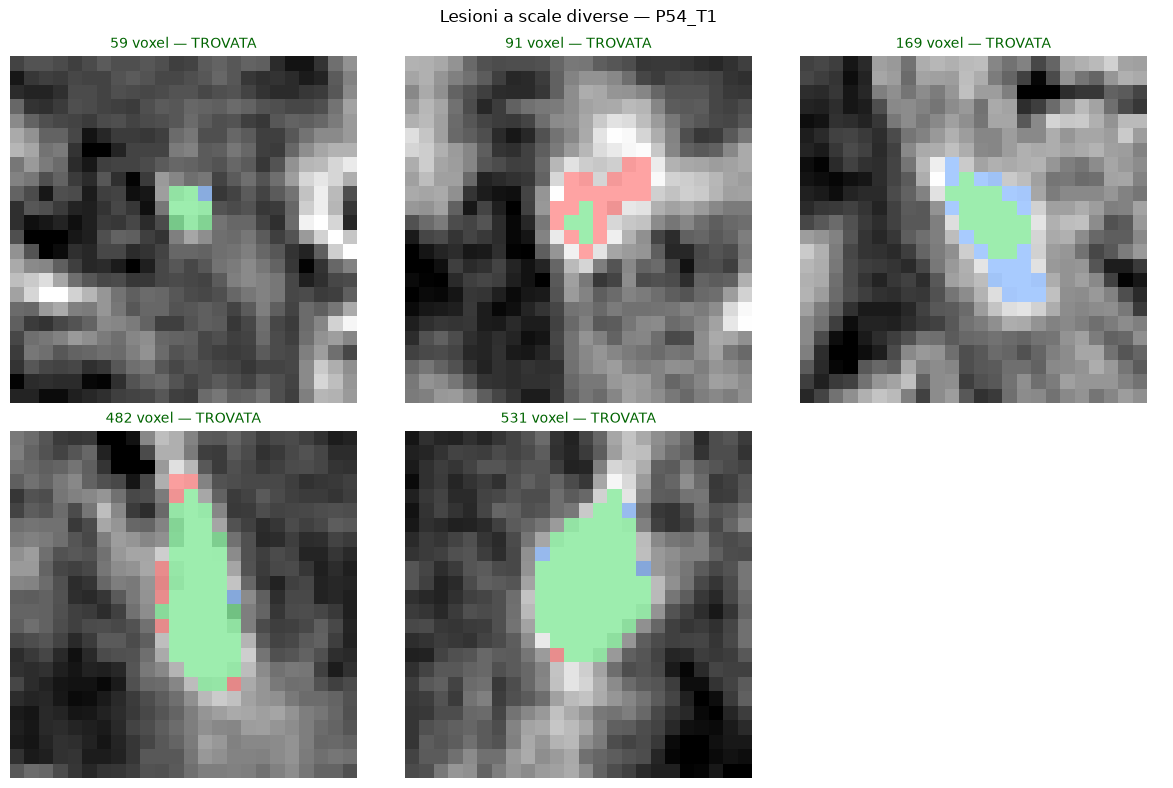

In [11]:
plot_case_overlay(img, gt, pred, case_name=CASE, n_slices=3); plt.show()
plot_lesion_zoom(img, gt, pred, case_name=CASE, n_lesions=6); plt.show()

### 8.4 Esploratore interattivo delle slice
Slider per scorrere il volume. Se `ipywidgets` non è installato (`pip install ipywidgets`),
viene mostrata una griglia statica delle slice più lesionate.

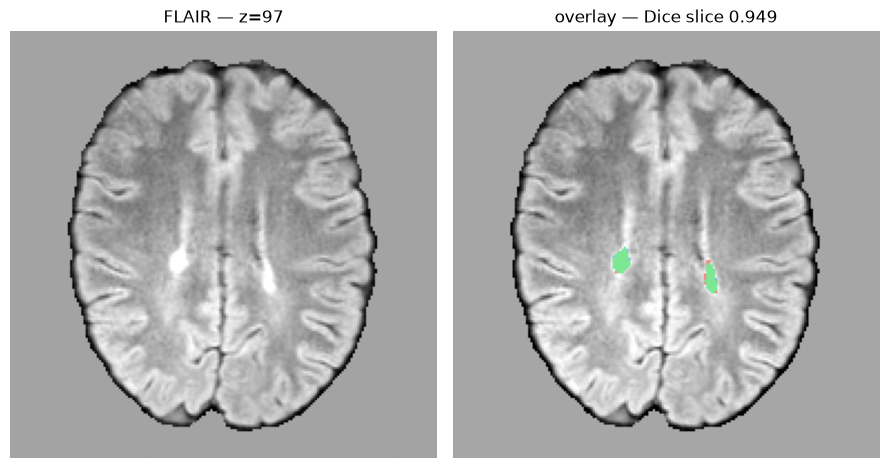

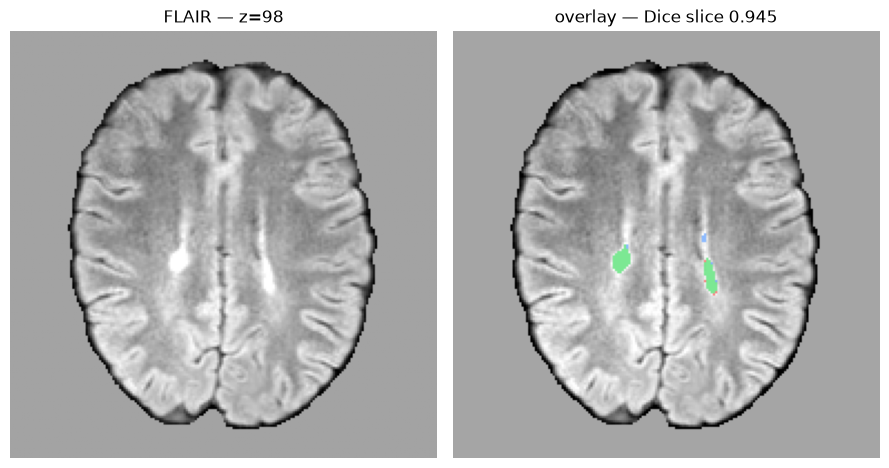

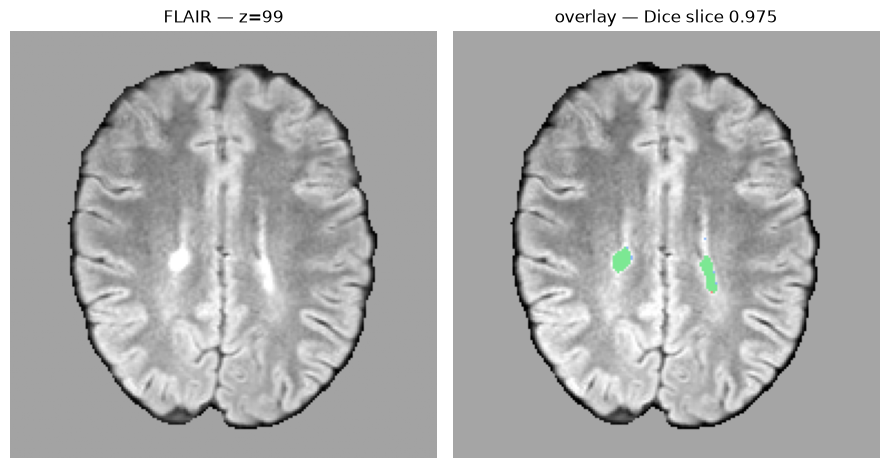

In [12]:
def show_slice(z):
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
    ax[0].imshow(np.rot90(img[z]), cmap="gray"); ax[0].set_title(f"FLAIR — z={z}")
    ax[1].imshow(overlay_rgb(img[z], gt[z], pred[z]))
    d = 2*(gt[z] & pred[z]).sum() / max(gt[z].sum()+pred[z].sum(), 1)
    ax[1].set_title(f"overlay — Dice slice {d:.3f}" if gt[z].sum() or pred[z].sum() else "overlay")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, IntSlider
    z0 = int(np.argmax(gt.reshape(len(gt), -1).sum(1)))
    interact(show_slice, z=IntSlider(min=0, max=len(img)-1, step=1, value=z0))
except ImportError:
    top = np.argsort(gt.reshape(len(gt), -1).sum(1))[::-1][:3]
    for z in sorted(int(z) for z in top):
        show_slice(z)

### 8.5 Pacchetto completo di figure
Genera tutte le figure su file in `<run>/figures/`, pronte per il report.

In [ ]:
!python scripts/05_visualize.py --run {RUN} --split {SPLIT} --device cpu

  [+] training_curves.png
  [+] results_overview.png
  device: cpu | casi disponibili: 22
  [+] overlay_P59_T1.png / lesion_zoom_P59_T1.png (Dice 0.410)
  [+] overlay_P68_T1.png / lesion_zoom_P68_T1.png (Dice 0.419)
  [+] overlay_P69_T1.png / lesion_zoom_P69_T1.png (Dice 0.820)
  [+] overlay_P72_T1.png / lesion_zoom_P72_T1.png (Dice 0.825)
      analisi dimensioni 1/22
      analisi dimensioni 2/22
      analisi dimensioni 3/22
      analisi dimensioni 4/22
      analisi dimensioni 5/22
      analisi dimensioni 6/22
      analisi dimensioni 7/22
      analisi dimensioni 8/22
      analisi dimensioni 9/22
      analisi dimensioni 10/22
      analisi dimensioni 11/22
      analisi dimensioni 12/22
      analisi dimensioni 13/22
      analisi dimensioni 14/22
      analisi dimensioni 15/22
      analisi dimensioni 16/22
      analisi dimensioni 17/22
      analisi dimensioni 18/22
      analisi dimensioni 19/22
      analisi dimensioni 20/22
      analisi dimensioni 21/22
      analisi di

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\massi\miniconda3\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\massi\miniconda3\Lib\asyncio\selector_events.py", line 132, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] Connessione in corso interrotta forzatamente dall'host remoto
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\massi\miniconda3\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\massi\miniconda3\Lib\asyncio\selector_events.py", line 132, in _read_from_self
    data = 

## Prossime fasi
- **Fase 6** — robustezza cross-protocollo (spessore di slice) + Jacobian
- **Fase 7** — fairness per sottogruppo, Grad-CAM e mappe di attenzione
- **Fase 9** — report LaTeX e model card